## Análisis del GRD para la desigualdad de acceso a hospitalización compleja

Utilizando la base de datos del GRD cruzada con: Base de Establecimientos (DIES), Camas Hospitalarias (DIES), Proyección de población del INE, CIE10 (diagnósticos) y estimación de la pobreza multidimensional (BIDAT), se realizará un análisis exploratorio de las variables clave:

In [1]:
import pandas as pd
from charset_normalizer import from_bytes
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob as gb

In [2]:
grd = pd.read_parquet('grd_procesado.parquet')

Primero, se entiende la estructura de nuestra base, conociendo sus variables, los tipos de datos que contiene, la cantidad de filas y columnas, etc.

In [3]:
# Verificamos si hay valores nulos o faltantes
print("Valores nulos por columna:")
print(grd.isnull().sum())

# Verificamos valores únicos en algunas columnas clave
print("\nValores únicos en columna SEXO:")
print(grd['SEXO'].unique())

# print("\nValores únicos en columna TIPOALTA:")
# print(grd['TIPOALTA'].unique())

print("\nValores unicos de severidad")
print(grd['IR_29301_SEVERIDAD'].unique())

print("--- df.head() ---")
display(grd.head())          # primeras 5 filas

print("\n--- df.shape ---")
print(grd.shape)            

print("\n--- df.info() ---")
grd.info()                   # tipos + nulos

print("\n--- df.describe() ---")
display(grd.describe())                    # estadísticas numéricas

print("\n--- df.describe(include='all') ---")
display(grd.describe(include="all"))       # incluye categóricas

Valores nulos por columna:
COD_ESTABLECIMIENTO       0
CIP_ENCRIPTADO            0
SEXO                      0
FECHA_NACIMIENTO          0
PROVINCIA                 0
                         ..
CAMAS_COMUNA              0
CRITICAS_COMUNA           0
CAMAS_1000HAB             0
CRITICAS_1000HAB          0
TASA_MORTALIDAD_COMUNA    0
Length: 87, dtype: int64

Valores únicos en columna SEXO:
['HOMBRE', 'MUJER', 'DESCONOCIDO']
Categories (3, object): ['DESCONOCIDO', 'HOMBRE', 'MUJER']

Valores unicos de severidad
['2', '3']
Categories (4, object): ['0', '1', '2', '3']
--- df.head() ---


,COD_ESTABLECIMIENTO,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,PROVINCIA,COMUNA_REGISTRADA,PREVISION,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,...,CAMAS_CRITICAS,POB_MULT_ESTAB,COMUNA_CON_ESTAB_AC,FALLECIDO,CRITICAS_PROP,CAMAS_COMUNA,CRITICAS_COMUNA,CAMAS_1000HAB,CRITICAS_1000HAB,TASA_MORTALIDAD_COMUNA
0,118100,467373,HOMBRE,1969-09-10,CONCEPCION,SAN PEDRO DE LA PAZ,FONASA INSTITUCIONAL - (MAI) B,CONCEPCIÓN,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,113,0.090303,0,0,0.128118,882,113,3.717488,0.476277,0.117963
1,118100,562854,HOMBRE,1956-02-07,CONCEPCION,CORONEL,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÓN,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,113,0.090303,1,0,0.128118,882,113,3.717488,0.476277,0.117963
2,118100,199980,MUJER,1960-02-28,CONCEPCION,SAN PEDRO DE LA PAZ,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÓN,APS CONSULTORIO (CESFAM),URGENCIA,...,113,0.090303,0,0,0.128118,882,113,3.717488,0.476277,0.117963
3,118100,857926,MUJER,1933-01-12,CONCEPCION,CHIGUAYANTE,FONASA INSTITUCIONAL - (MAI) D,CONCEPCIÓN,"OTRAS INSTITUCIONES SALUD (CLÍNICAS PRIVADAS, ...",URGENCIA,...,113,0.090303,0,1,0.128118,882,113,3.717488,0.476277,0.117963
4,118100,284629,HOMBRE,1951-05-03,CURICO,TENO,FONASA INSTITUCIONAL - (MAI) C,DEL MAULE,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,...,113,0.090303,0,0,0.128118,882,113,3.717488,0.476277,0.117963



--- df.shape ---
(367895, 87)

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367895 entries, 0 to 367894
Data columns (total 87 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   COD_ESTABLECIMIENTO     367895 non-null  category      
 1   CIP_ENCRIPTADO          367895 non-null  string        
 2   SEXO                    367895 non-null  category      
 3   FECHA_NACIMIENTO        367895 non-null  datetime64[ns]
 4   PROVINCIA               367895 non-null  category      
 5   COMUNA_REGISTRADA       367895 non-null  category      
 6   PREVISION               367895 non-null  category      
 7   SERVICIO_SALUD          367895 non-null  category      
 8   TIPO_PROCEDENCIA        367895 non-null  category      
 9   TIPO_INGRESO            367895 non-null  category      
 10  FECHA_INGRESO           367895 non-null  datetime64[ns]
 11  FECHAALTA               367895 non-null  

,FECHA_NACIMIENTO,FECHA_INGRESO,FECHAALTA,IR_29301_PESO,YEAR,EDAD,DIAS_ESTANCIA,N_COMORBILIDADES,N_PROCEDIMIENTOS,INDICE_CHARLSON,...,CAMAS_CRITICAS,POB_MULT_ESTAB,COMUNA_CON_ESTAB_AC,FALLECIDO,CRITICAS_PROP,CAMAS_COMUNA,CRITICAS_COMUNA,CAMAS_1000HAB,CRITICAS_1000HAB,TASA_MORTALIDAD_COMUNA
count,367895,367895,367895,367895.000000,367895.000000,367895.000000,367895.000000,367895.000000,367895.000000,367895.000000,...,367895.0,367895.000000,367895.000000,367895.000000,367895.0,367895.0,367895.0,367895.0,367895.0,367895.000000
mean,1971-03-01 15:04:47.602712728,2022-02-24 16:37:58.667554560,2022-03-19 20:29:42.469454080,4.158070,2021.659088,50.987017,23.160924,7.095908,19.000196,1.369516,...,88.371122,0.153238,0.596526,0.175920,0.195109,603.878218,122.771674,2.649175,0.508375,0.175792
min,1912-02-21 00:00:00,2019-01-01 00:00:00,2019-01-01 00:00:00,2.008300,2019.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.017689,0.000000,0.000000,0.0,57.0,0.0,0.715688,0.0,0.099017
25%,1951-05-28 00:00:00,2020-10-08 00:00:00,2020-11-02 00:00:00,2.282800,2020.000000,34.500000,7.000000,5.000000,12.000000,0.000000,...,53.0,0.123584,0.000000,0.000000,0.151685,391.0,60.0,1.530982,0.275109,0.150477
50%,1963-10-19 00:00:00,2022-03-11 00:00:00,2022-04-05 00:00:00,3.267000,2022.000000,58.400000,15.000000,8.000000,19.000000,1.000000,...,83.0,0.153808,1.000000,0.000000,0.188088,558.0,119.0,2.347127,0.448737,0.167554
75%,1987-09-01 00:00:00,2023-08-17 00:00:00,2023-09-08 00:00:00,5.820700,2023.000000,70.800000,29.000000,9.000000,27.000000,2.000000,...,125.0,0.186940,1.000000,0.000000,0.231343,749.0,152.0,3.328457,0.625691,0.207692
max,2024-12-27 00:00:00,2024-12-31 00:00:00,2024-12-31 00:00:00,20.646100,2024.000000,108.200000,1266.000000,9.000000,30.000000,54.000000,...,207.0,0.359106,1.000000,1.000000,0.896104,1448.0,418.0,7.161665,1.394621,0.312339
std,NaN,NaN,NaN,2.586461,1.673167,26.229025,29.861072,2.327498,8.353354,2.221889,...,46.613627,0.063248,0.490595,0.380752,0.083231,313.490296,84.802603,1.427972,0.325749,0.043621



--- df.describe(include='all') ---


,COD_ESTABLECIMIENTO,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,PROVINCIA,COMUNA_REGISTRADA,PREVISION,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,...,CAMAS_CRITICAS,POB_MULT_ESTAB,COMUNA_CON_ESTAB_AC,FALLECIDO,CRITICAS_PROP,CAMAS_COMUNA,CRITICAS_COMUNA,CAMAS_1000HAB,CRITICAS_1000HAB,TASA_MORTALIDAD_COMUNA
count,367895,367895,367895,367895,367895,367895,367895,367895,367895,367895,...,367895.0,367895.000000,367895.000000,367895.000000,367895.0,367895.0,367895.0,367895.0,367895.0,367895.000000
unique,72,325342,3,NaN,58,346,15,32,18,5,...,<NA>,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
top,114101,DESCONOCIDO,HOMBRE,NaN,SANTIAGO,PUENTE ALTO,FONASA INSTITUCIONAL - (MAI) B,METROPOLITANO SURORIENTE,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,<NA>,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
freq,19913,327,213422,NaN,101902,14977,190248,34956,180779,301253,...,<NA>,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN
mean,NaN,NaN,NaN,1971-03-01 15:04:47.602712728,NaN,NaN,NaN,NaN,NaN,NaN,...,88.371122,0.153238,0.596526,0.175920,0.195109,603.878218,122.771674,2.649175,0.508375,0.175792
min,NaN,NaN,NaN,1912-02-21 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.017689,0.000000,0.000000,0.0,57.0,0.0,0.715688,0.0,0.099017
25%,NaN,NaN,NaN,1951-05-28 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,53.0,0.123584,0.000000,0.000000,0.151685,391.0,60.0,1.530982,0.275109,0.150477
50%,NaN,NaN,NaN,1963-10-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,83.0,0.153808,1.000000,0.000000,0.188088,558.0,119.0,2.347127,0.448737,0.167554
75%,NaN,NaN,NaN,1987-09-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,125.0,0.186940,1.000000,0.000000,0.231343,749.0,152.0,3.328457,0.625691,0.207692
max,NaN,NaN,NaN,2024-12-27 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,207.0,0.359106,1.000000,1.000000,0.896104,1448.0,418.0,7.161665,1.394621,0.312339


Se realizan diferentes filtros para poder conocer mejor a los pacientes a nivel demográfico, utilizando sexo y edad.

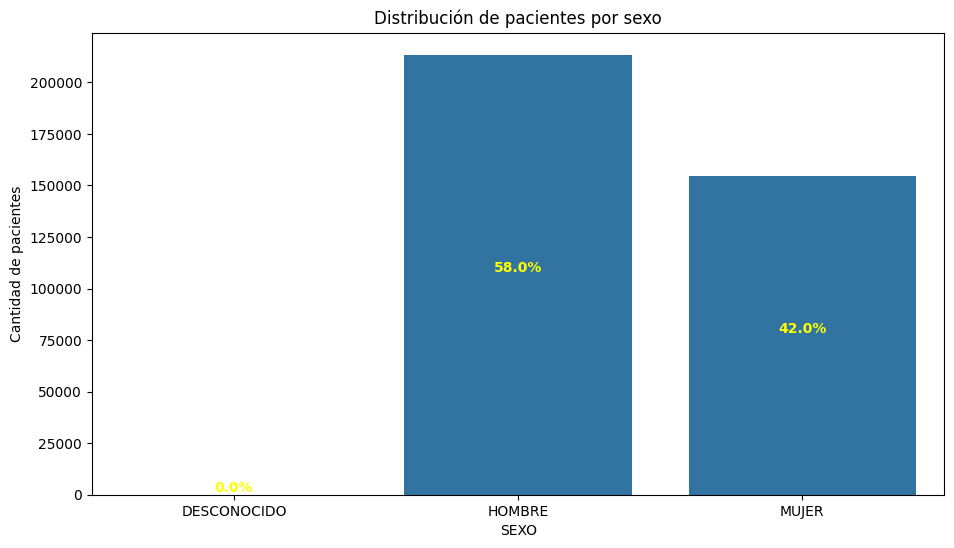

In [4]:
plt.figure(figsize=(11, 6))
ax = sns.countplot(data=grd, x='SEXO')
plt.title('Distribución de pacientes por sexo')
plt.ylabel('Cantidad de pacientes')
plt.xticks(rotation=0)

# Añadir porcentaje en las barras
total = len(grd)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() /2
    ax.annotate(percentage, (x, y), ha='center', va='bottom', color='yellow', weight='bold')

plt.show()

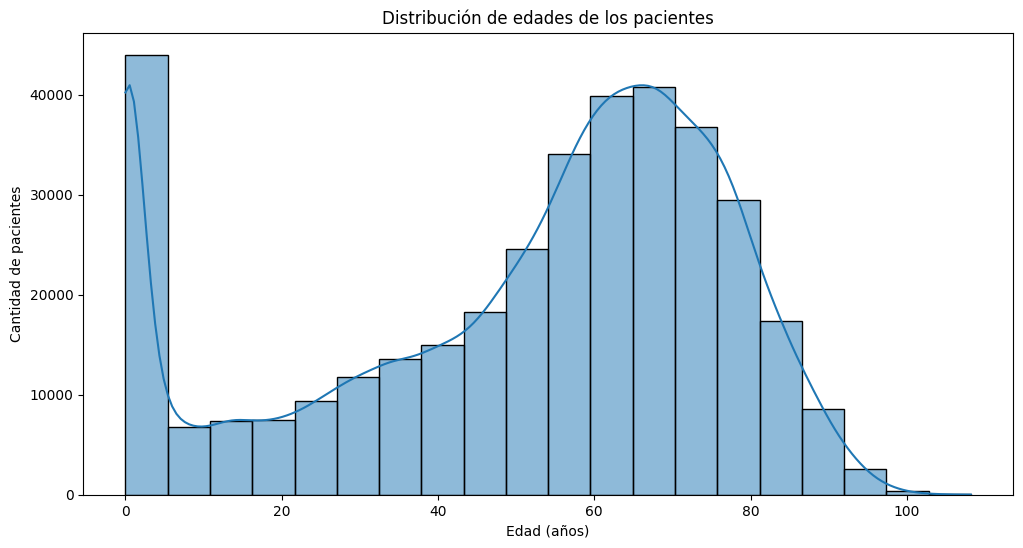

In [5]:
plt.figure(figsize=(12, 6))
# Filter data and convert EDAD to float to ensure compatibility with KDE
# edad_data = grdtest.dropna(subset=['EDAD'])['EDAD'].astype(float)
sns.histplot(grd['EDAD'], bins=20, kde=True)
plt.title('Distribución de edades de los pacientes')
plt.xlabel('Edad (años)')
plt.ylabel('Cantidad de pacientes')
plt.show()

Se estudian variables clave, como la severidad de los pacientes y dias de estancia, para poder entender como se distribuyen en paciente de hospitalización compleja.

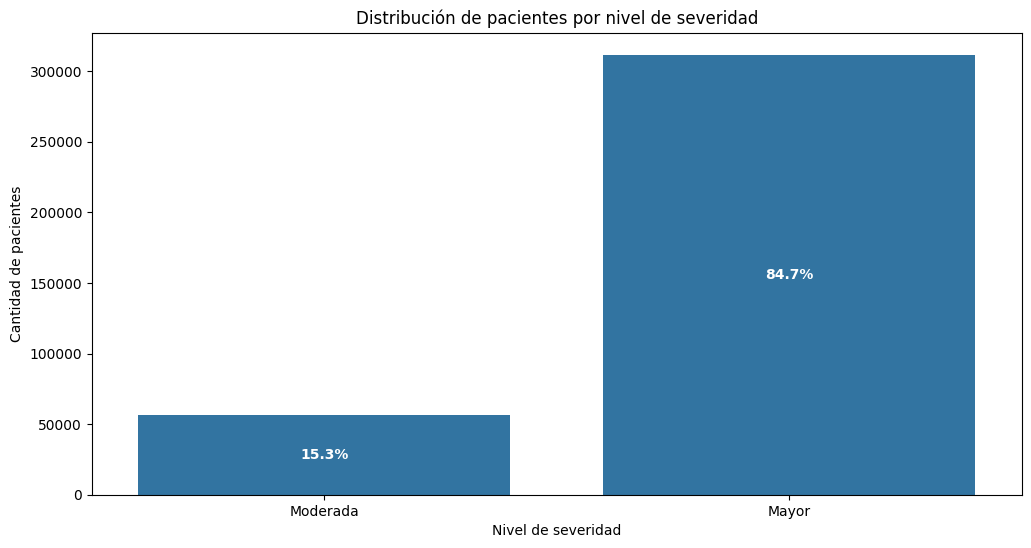

In [6]:
grd['IR_29301_SEVERIDAD'] = grd.IR_29301_SEVERIDAD.astype('string').astype('category')
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=grd, x='IR_29301_SEVERIDAD')
plt.title('Distribución de pacientes por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Cantidad de pacientes')
plt.xticks(ticks=[0, 1], labels=['Moderada', 'Mayor'])

# Añadir porcentaje en las barras
total = len(grd)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() / 2
    ax.annotate(percentage, (x, y), ha='center', va='center', color='white', weight='bold')

plt.show()

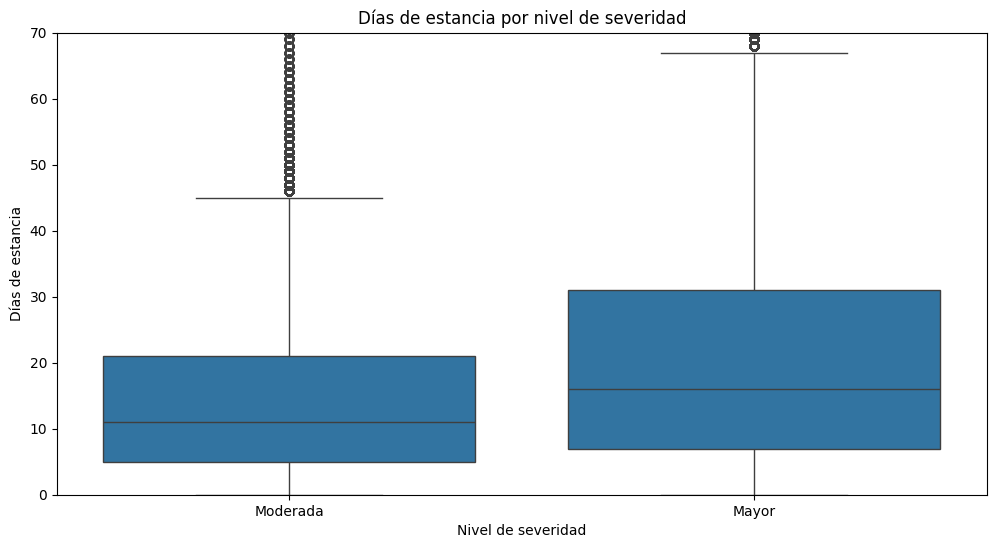

In [7]:
# Relación entre severidad y días de estancia
plt.figure(figsize=(12, 6))
sns.boxplot(data=grd, x='IR_29301_SEVERIDAD', y='DIAS_ESTANCIA')
plt.title('Días de estancia por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Días de estancia')
plt.xticks(ticks=[0, 1], labels=['Moderada', 'Mayor'])
plt.ylim(0, 70)  # Limitamos el eje Y para mejor visualización
plt.show()

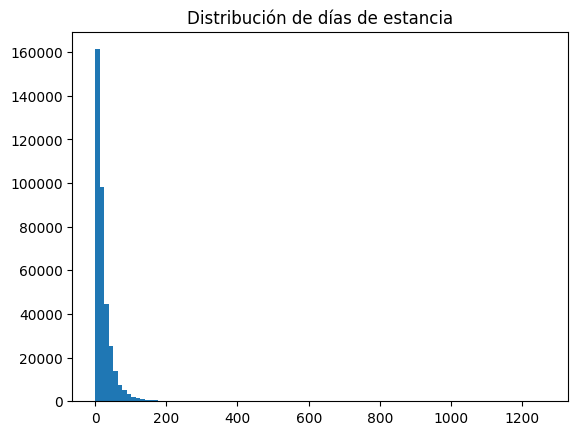

In [8]:
plt.hist(grd['DIAS_ESTANCIA'], bins=100)
plt.title('Distribución de días de estancia')
plt.show()

In [9]:
grd[grd['DIAS_ESTANCIA'] >= 400]['DIAS_ESTANCIA'].value_counts()

DIAS_ESTANCIA
407    5
419    4
489    4
458    3
400    3
      ..
484    1
579    1
503    1
630    1
456    1
Name: count, Length: 131, dtype: int64

Obtenemos ahora datos sobre la cantidad de pacientes y diagnosticos segun Servicio de Salud.

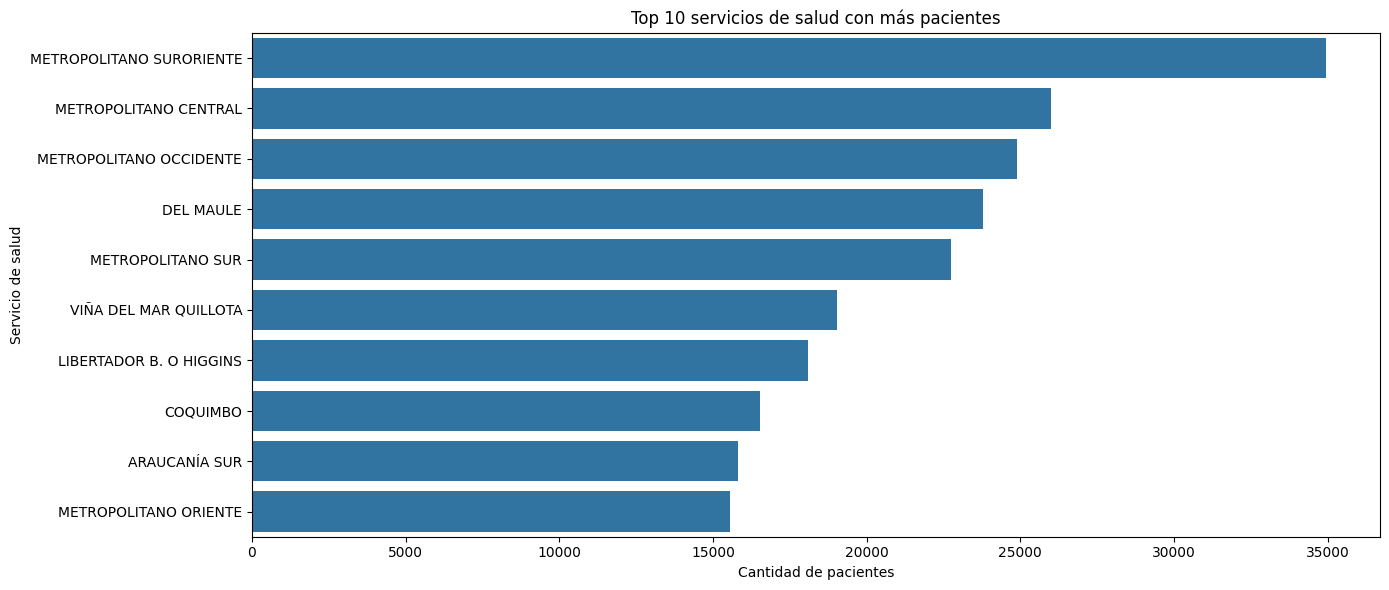

In [10]:
# Top 10 servicios de salud con más pacientes
plt.figure(figsize=(14, 6))
top_10_servicios = grd['SERVICIO_SALUD'].value_counts().head(10)
top_10_servicios.index = top_10_servicios.index.astype('string')
sns.barplot(top_10_servicios, orient='h')
plt.title('Top 10 servicios de salud con más pacientes')
plt.ylabel('Servicio de salud')
plt.xlabel('Cantidad de pacientes')
plt.tight_layout()
plt.show()

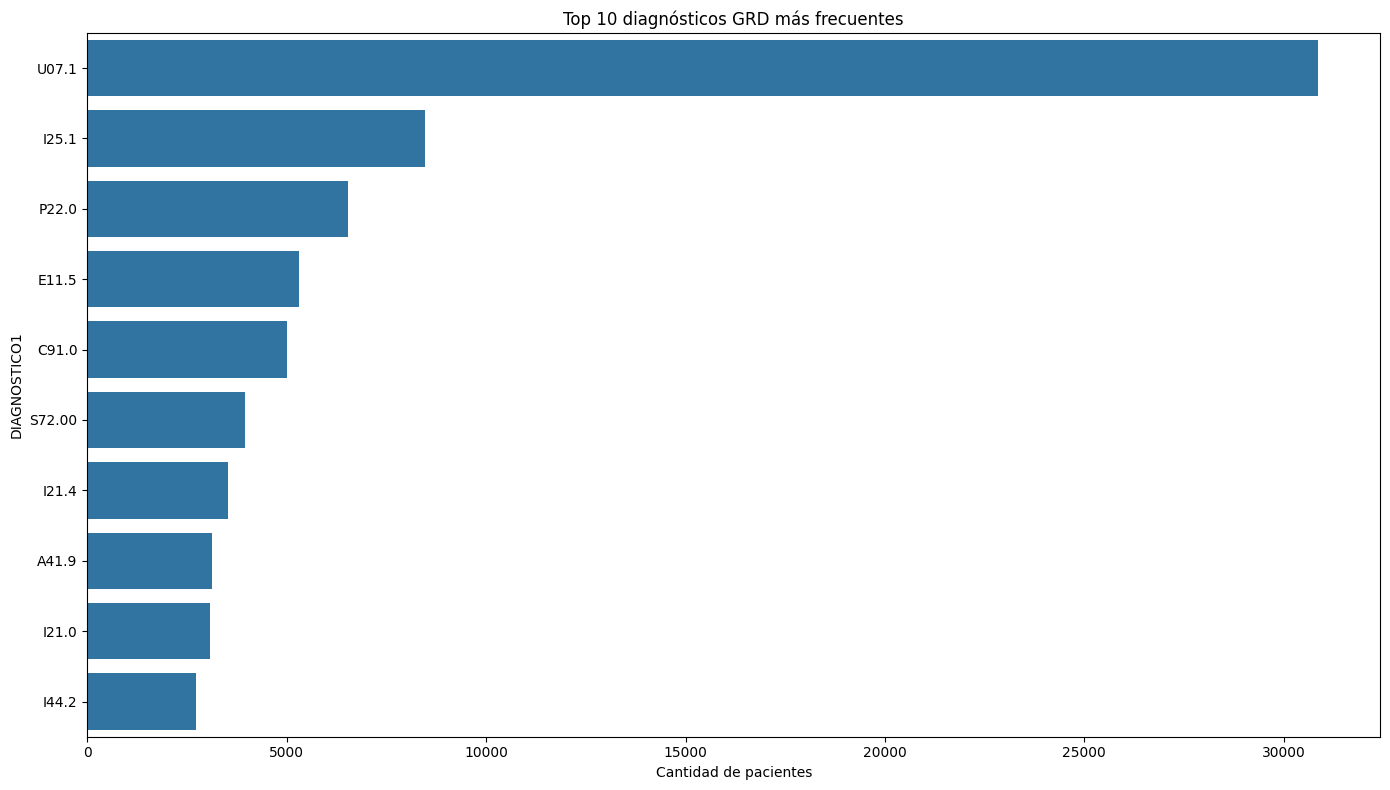

In [11]:
# Top 10 diagnósticos más frecuentes
plt.figure(figsize=(14, 8))
top_10_grd = grd['DIAGNOSTICO1'].value_counts().head(10)
sns.barplot(x=top_10_grd.values, y=top_10_grd.index)
plt.title('Top 10 diagnósticos GRD más frecuentes')
plt.xlabel('Cantidad de pacientes')
plt.tight_layout()
plt.show()

Se combinan variables anteriores para ver con más detalle relaciones entre severidad, edad, sexo, etc. 

<Figure size 3000x1000 with 0 Axes>

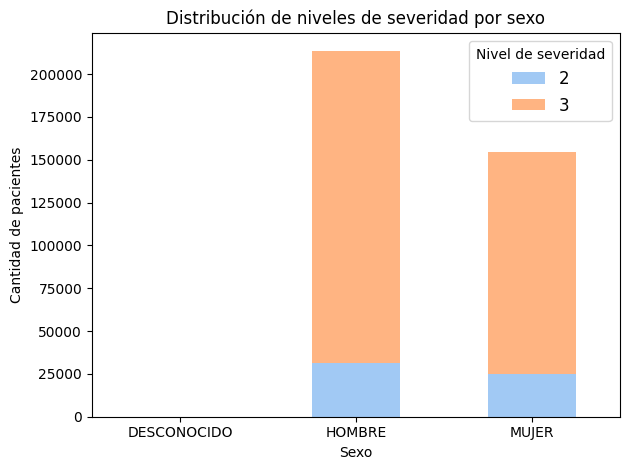

In [12]:
plt.figure(figsize=(30, 10))
crosstab = pd.crosstab(grd['SEXO'], grd['IR_29301_SEVERIDAD'])
crosstab.plot(kind='bar', stacked=True, color=sns.color_palette("pastel"))
plt.title('Distribución de niveles de severidad por sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de pacientes')
plt.legend(title='Nivel de severidad', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


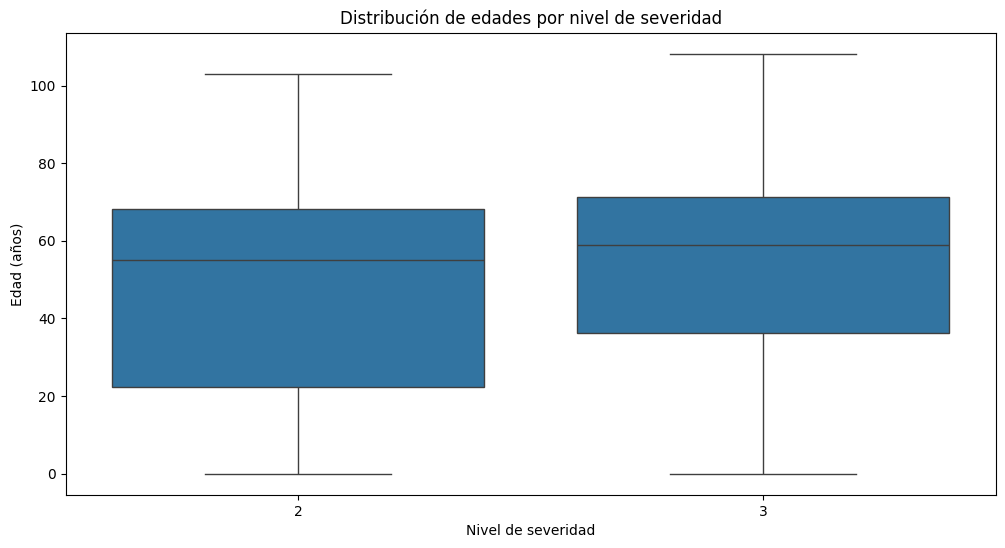

In [13]:
# Relación entre edad y severidad
plot_data = grd.dropna(subset=['IR_29301_SEVERIDAD', 'EDAD']).copy()
plot_data['IR_29301_SEVERIDAD'] = plot_data['IR_29301_SEVERIDAD'].astype('category')
plot_data['EDAD'] = plot_data['EDAD'].astype(float)

plt.figure(figsize=(12, 6))
sns.boxplot(data=plot_data, x='IR_29301_SEVERIDAD', y='EDAD')
plt.title('Distribución de edades por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Edad (años)')
plt.show()

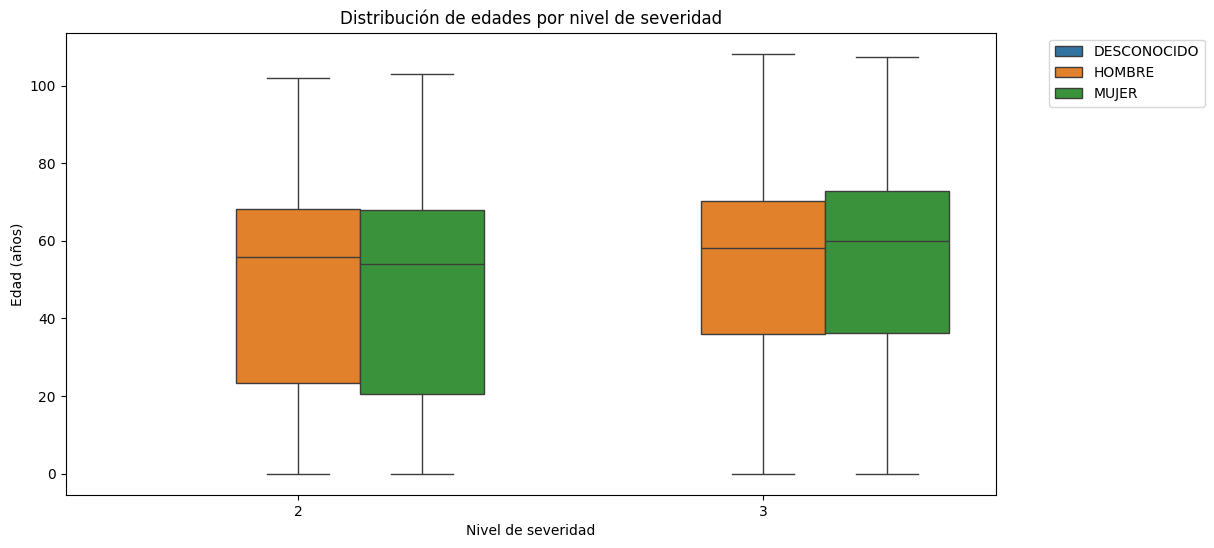

In [14]:
plt.figure(figsize=(12, 6))
data = grd[grd['SEXO'].notna() & (grd['SEXO'] != 'DESCONOCIDO')].dropna(subset=['EDAD', 'IR_29301_SEVERIDAD'])
sns.boxplot(data=data, x='IR_29301_SEVERIDAD', y='EDAD', hue='SEXO')
plt.title('Distribución de edades por nivel de severidad')
plt.xlabel('Nivel de severidad')
plt.ylabel('Edad (años)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Mueve la leyenda fuera del área del gráfico
plt.show()

Se comparan los top 5 hospitales según su peso promedio de GRD, que indica los costos en relación a una hospitalización promedio.

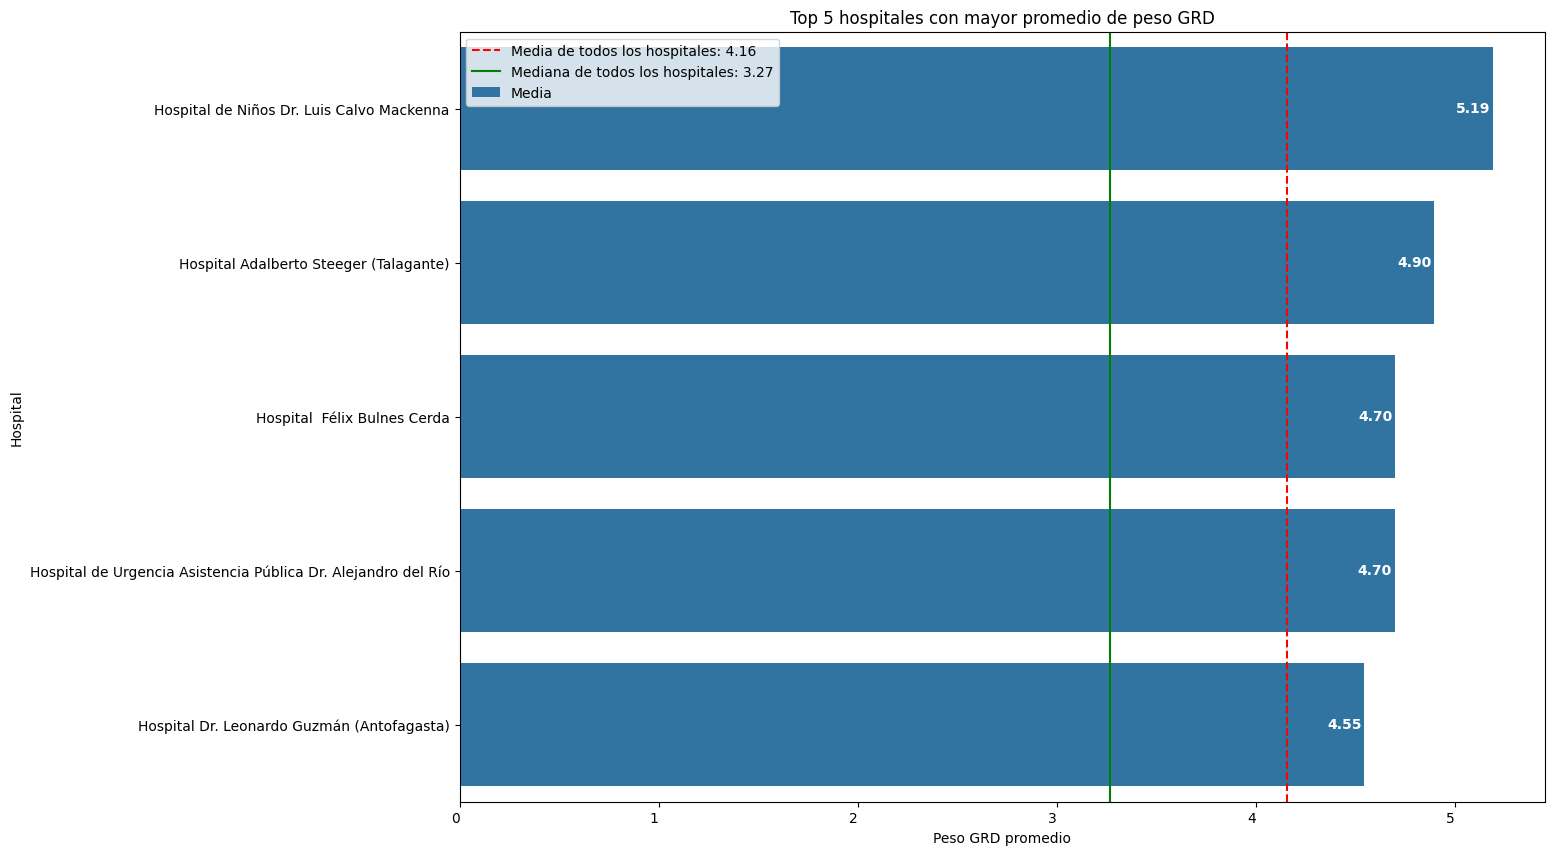

In [15]:
# Top 5 hospitales con mayor promedio de peso GRD (mayor complejidad)
# df_hospitales = pd.read_csv("datos/Hospitales.csv", header=None, names=['COD_HOSPITAL', 'NOMBRE_HOSPITAL'], sep="|")
hospital_peso = grd.groupby('ESTABLECIMIENTO')['IR_29301_PESO'].agg(['mean', 'median', 'count'])
hospital_peso = hospital_peso[hospital_peso['count'] > 100]  # Filtramos hospitales con pocos casos
hospital_peso = hospital_peso.sort_values('mean', ascending=False).head(5)

# Calculamos la media y mediana de todos los hospitales
mean_all = grd['IR_29301_PESO'].mean()
median_all = grd['IR_29301_PESO'].median()

plt.figure(figsize=(14, 10))
ax = sns.barplot(y=hospital_peso.index, x=hospital_peso['mean'], orient='h', label='Media')
plt.title('Top 5 hospitales con mayor promedio de peso GRD')
plt.ylabel('Hospital')
plt.xlabel('Peso GRD promedio')
plt.xticks(rotation=0, ha='right')

# Añadimos líneas verticales para la media y mediana de todos los hospitales
plt.axvline(mean_all, color='r', linestyle='--', label=f'Media de todos los hospitales: {mean_all:.2f}')
plt.axvline(median_all, color='g', linestyle='-', label=f'Mediana de todos los hospitales: {median_all:.2f}')

# Añadimos el promedio dentro de la barra en color blanco
for p in ax.patches:
    width = p.get_width()
    plt.text(width - 0.1, p.get_y() + p.get_height() / 2, f'{width:.2f}', ha='center', va='center', color='white', weight='bold')

plt.legend()
plt.show()


Se busca agrupar los datos por comuna, para poder conocer los diagnósticos más frecuentes, además de filtrar por comunas que no tengan presencia de hospital GRD de alta complejidad, para identificar brechas de acceso.

In [16]:
lejos = grd[grd['COMUNA_REGISTRADA'] != grd['COMUNA_ESTAB']]
display(lejos.groupby('COMUNA_REGISTRADA')['CIP_ENCRIPTADO'].count().sort_values(ascending=False), )

/tmp/ipykernel_16988/1492853395.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(lejos.groupby('COMUNA_REGISTRADA')['CIP_ENCRIPTADO'].count().sort_values(ascending=False), )


COMUNA_REGISTRADA
PUDAHUEL            4701
LA PINTANA          4684
EL BOSQUE           3987
ESTACION CENTRAL    3786
MAIPU               3380
                    ... 
TORRES DEL PAINE       1
ANTARTICA              1
RIO VERDE              1
GENERAL LAGOS          1
TIMAUKEL               1
Name: CIP_ENCRIPTADO, Length: 346, dtype: int64

In [17]:
lejos10 = lejos['COMUNA_REGISTRADA'].value_counts().head(10)
for comuna in lejos10.index:
    a = grd[grd['COMUNA_REGISTRADA'] == comuna]['DIAGNOSTICO1'].value_counts()
    display(a)

DIAGNOSTICO1
U07.1     459
P22.0     100
I21.4      87
I21.0      60
I25.1      51
         ... 
Q41.0       1
S32.70      1
T85.9       1
S49.8       1
S80.7       1
Name: count, Length: 1115, dtype: Int64

DIAGNOSTICO1
U07.1     417
P22.0      82
C91.0      67
E11.5      66
I77.1      66
         ... 
I65.2       1
S39.6       1
S27.71      1
D12.0       1
S31.2       1
Name: count, Length: 1132, dtype: Int64

DIAGNOSTICO1
U07.1     363
A41.8      77
E11.5      72
P22.0      57
J18.9      56
         ... 
M53.26      1
C07         1
T79.7       1
A18.4       1
S85.0       1
Name: count, Length: 974, dtype: Int64

DIAGNOSTICO1
U07.1     411
I25.1     114
C91.0      56
I21.0      42
C92.0      41
         ... 
I60.0       1
F31.2       1
N18.4       1
M65.14      1
T84.3       1
Name: count, Length: 993, dtype: Int64

DIAGNOSTICO1
U07.1     1194
I25.1      236
P07.1      205
S72.00     183
P07.3      183
          ... 
K21.9        1
N31.9        1
M84.07       1
C84.9        1
E16.1        1
Name: count, Length: 1487, dtype: Int64

DIAGNOSTICO1
U07.1     526
E11.5      70
P22.0      66
J12.1      66
A41.8      63
         ... 
S06.30      1
G91.8       1
C54.1       1
F84.0       1
S36.50      1
Name: count, Length: 1186, dtype: Int64

DIAGNOSTICO1
U07.1     308
P22.0      65
J18.9      47
J12.1      43
I21.4      35
         ... 
Q85.9       1
P04.4       1
S82.90      1
S97.0       1
C76.0       1
Name: count, Length: 845, dtype: Int64

DIAGNOSTICO1
U07.1     243
I25.1      58
S72.00     58
P22.0      46
S72.10     45
         ... 
E11.1       1
I80.1       1
I45.8       1
K63.0       1
M00.88      1
Name: count, Length: 864, dtype: Int64

DIAGNOSTICO1
U07.1    491
P22.0     91
Z45.0     90
I25.1     70
C92.0     67
        ... 
K41.0      1
I08.9      1
G61.9      1
J98.5      1
M50.2      1
Name: count, Length: 1164, dtype: Int64

DIAGNOSTICO1
U07.1     152
Z45.0     125
I25.1      52
S72.00     42
I35.0      35
         ... 
S11.8       1
M46.36      1
K66.0       1
R59.0       1
S36.51      1
Name: count, Length: 844, dtype: Int64

## Estimacion estadistica (estimadores puntuales)

En esta seccion seguimos la misma linea del EDA para obtener estimadores puntuales de parametros de interes:

- Promedios (media muestral)
- Proporciones (proporcion muestral)

Primero se calcula un resumen global del dataset cargado en `grd`.

In [18]:
import pandas as pd

if 'grd' not in globals():
    grd = pd.read_parquet('grd_procesado.parquet')

# Parametros para promedio
vars_promedio = ['EDAD', 'DIAS_ESTANCIA', 'IR_29301_PESO']

# Parametros para proporcion 
def evento_severidad_mayor(df):
    return df['IR_29301_SEVERIDAD'].astype('string').eq('3')

def evento_sexo_femenino(df):
    return df['SEXO'].astype('string').str.upper().eq('F')

proporciones = {
    'Proporcion severidad mayor (IR_29301_SEVERIDAD = 3)': evento_severidad_mayor,
    'Proporcion sexo femenino (SEXO = F)': evento_sexo_femenino,
}

filas = []

# 1) Estimadores puntuales de medias
for var in vars_promedio:
    serie = pd.to_numeric(grd[var], errors='coerce').dropna()
    n = int(serie.shape[0])
    if n > 0:
        filas.append({
            'Parametro': f'Media poblacional de {var}',
            'Tipo_estimador': 'Media muestral',
            'Estimador_puntual': float(serie.mean()),
            'N_utilizado': n
        })

# 2) Estimadores puntuales de proporciones
for nombre_parametro, regla in proporciones.items():
    indicador = regla(grd)
    indicador = indicador.where(indicador.notna()).dropna()
    n = int(indicador.shape[0])
    if n > 0:
        filas.append({
            'Parametro': nombre_parametro,
            'Tipo_estimador': 'Proporcion muestral',
            'Estimador_puntual': float(indicador.mean()),
            'N_utilizado': n
        })

# Tabla resumen final
tabla_estimadores = pd.DataFrame(filas)
tabla_estimadores['Estimador_puntual'] = tabla_estimadores['Estimador_puntual'].round(4)

print('Tabla de resumen de estimadores puntuales:')
display(tabla_estimadores)


Tabla de resumen de estimadores puntuales:


,Parametro,Tipo_estimador,Estimador_puntual,N_utilizado
0,Media poblacional de EDAD,Media muestral,50.9870,367895
1,Media poblacional de DIAS_ESTANCIA,Media muestral,23.1609,367895
2,Media poblacional de IR_29301_PESO,Media muestral,4.1581,367895
3,Proporcion severidad mayor (IR_29301_SEVERIDAD...,Proporcion muestral,0.8472,367895
4,Proporcion sexo femenino (SEXO = F),Proporcion muestral,0.0000,367895


## Ajuste de proporciones y analisis por año

Para mantener consistencia con el EDA, primero identificamos como esta codificada la variable `SEXO` y definimos una regla para estimar la proporcion femenina.

Luego calculamos estimadores puntuales por año y agregamos intervalos de confianza al 95% para medias y proporciones.

In [19]:
import numpy as np
import pandas as pd

if 'grd' not in globals():
    grd = pd.read_parquet('grd_procesado.parquet')

# Inspeccion rapida de codigos de sexo para definir regla coherente
sexo_vals = grd['SEXO'].astype('string').str.strip().str.upper()
print('Valores unicos observados en SEXO:')
print(sorted(sexo_vals.dropna().unique().tolist()))

# Regla: considera codigos frecuentes de femenino en fuentes administrativas
def evento_sexo_femenino_robusto(df):
    vals = df['SEXO'].astype('string').str.strip().str.upper()
    codigos_femenino = {'F', 'FEMENINO', 'MUJER', '2'}
    codigos_validos = codigos_femenino.union({'M', 'MASCULINO', 'HOMBRE', '1'})

    # Se consideran como validos solo codigos hombre/mujer esperados
    es_valido = vals.isin(codigos_validos)
    indicador = vals.isin(codigos_femenino)
    return indicador.where(es_valido)

# Recalculo de la tabla global con regla corregida para sexo
vars_promedio = ['EDAD', 'DIAS_ESTANCIA', 'IR_29301_PESO']
proporciones = {
    'Proporcion severidad mayor (IR_29301_SEVERIDAD = 3)': lambda d: d['IR_29301_SEVERIDAD'].astype('string').eq('3'),
    'Proporcion sexo femenino (regla robusta)': evento_sexo_femenino_robusto,
}

filas = []
for var in vars_promedio:
    serie = pd.to_numeric(grd[var], errors='coerce').dropna()
    n = int(serie.shape[0])
    if n > 0:
        filas.append({
            'Ambito': 'Global',
            'Parametro': f'Media poblacional de {var}',
            'Tipo_estimador': 'Media muestral',
            'Estimador_puntual': float(serie.mean()),
            'N_utilizado': n
        })

for nombre_parametro, regla in proporciones.items():
    indicador = regla(grd)
    indicador = indicador.dropna()
    n = int(indicador.shape[0])
    if n > 0:
        filas.append({
            'Ambito': 'Global',
            'Parametro': nombre_parametro,
            'Tipo_estimador': 'Proporcion muestral',
            'Estimador_puntual': float(indicador.mean()),
            'N_utilizado': n
        })

tabla_estimadores_global = pd.DataFrame(filas)
tabla_estimadores_global['Estimador_puntual'] = tabla_estimadores_global['Estimador_puntual'].round(4)

print('Tabla global actualizada:')
display(tabla_estimadores_global)

Valores unicos observados en SEXO:
['DESCONOCIDO', 'HOMBRE', 'MUJER']
Tabla global actualizada:


,Ambito,Parametro,Tipo_estimador,Estimador_puntual,N_utilizado
0,Global,Media poblacional de EDAD,Media muestral,50.9870,367895
1,Global,Media poblacional de DIAS_ESTANCIA,Media muestral,23.1609,367895
2,Global,Media poblacional de IR_29301_PESO,Media muestral,4.1581,367895
3,Global,Proporcion severidad mayor (IR_29301_SEVERIDAD...,Proporcion muestral,0.8472,367895
4,Global,Proporcion sexo femenino (regla robusta),Proporcion muestral,0.4198,367853


In [20]:
# Estimadores puntuales por año
if 'Year' not in grd.columns:
    grd['Year'] = pd.to_datetime(grd['FECHA_INGRESO'], errors='coerce').dt.year

filas_year = []
for year, g in grd.dropna(subset=['Year']).groupby('Year'):
    # Medias
    for var in ['EDAD', 'DIAS_ESTANCIA', 'IR_29301_PESO']:
        serie = pd.to_numeric(g[var], errors='coerce').dropna()
        n = int(serie.shape[0])
        if n > 0:
            filas_year.append({
                'Ambito': f'Year={int(year)}',
                'Year': int(year),
                'Parametro': f'Media poblacional de {var}',
                'Tipo_estimador': 'Media muestral',
                'Estimador_puntual': float(serie.mean()),
                'N_utilizado': n
            })

    # Proporciones
    ind_sev = g['IR_29301_SEVERIDAD'].astype('string').eq('3').dropna()
    if ind_sev.shape[0] > 0:
        filas_year.append({
            'Ambito': f'Year={int(year)}',
            'Year': int(year),
            'Parametro': 'Proporcion severidad mayor (IR_29301_SEVERIDAD = 3)',
            'Tipo_estimador': 'Proporcion muestral',
            'Estimador_puntual': float(ind_sev.mean()),
            'N_utilizado': int(ind_sev.shape[0])
        })

    ind_fem = evento_sexo_femenino_robusto(g).dropna()
    if ind_fem.shape[0] > 0:
        filas_year.append({
            'Ambito': f'Year={int(year)}',
            'Year': int(year),
            'Parametro': 'Proporcion sexo femenino (regla)',
            'Tipo_estimador': 'Proporcion muestral',
            'Estimador_puntual': float(ind_fem.mean()),
            'N_utilizado': int(ind_fem.shape[0])
        })

tabla_estimadores_year = pd.DataFrame(filas_year)
tabla_estimadores_year['Estimador_puntual'] = tabla_estimadores_year['Estimador_puntual'].round(4)

print('Tabla de estimadores puntuales por anio:')
display(tabla_estimadores_year.sort_values(['Year', 'Tipo_estimador', 'Parametro']).reset_index(drop=True))

Tabla de estimadores puntuales por anio:


,Ambito,Year,Parametro,Tipo_estimador,Estimador_puntual,N_utilizado
0,Year=2019,2019,Media poblacional de DIAS_ESTANCIA,Media muestral,24.0087,50135
1,Year=2019,2019,Media poblacional de EDAD,Media muestral,49.3876,50135
2,Year=2019,2019,Media poblacional de IR_29301_PESO,Media muestral,3.9352,50135
3,Year=2019,2019,Proporcion severidad mayor (IR_29301_SEVERIDAD...,Proporcion muestral,0.8129,50135
4,Year=2019,2019,Proporcion sexo femenino (regla),Proporcion muestral,0.4311,50129
5,Year=2020,2020,Media poblacional de DIAS_ESTANCIA,Media muestral,24.0649,54370
6,Year=2020,2020,Media poblacional de EDAD,Media muestral,51.0162,54370
7,Year=2020,2020,Media poblacional de IR_29301_PESO,Media muestral,4.3668,54370
8,Year=2020,2020,Proporcion severidad mayor (IR_29301_SEVERIDAD...,Proporcion muestral,0.8635,54370
9,Year=2020,2020,Proporcion sexo femenino (regla),Proporcion muestral,0.4013,54354


In [21]:
# Intervalos de confianza (95%) para estimadores globales y por año

Z_95 = 1.96

def agregar_ic95(tabla):
    out = tabla.copy()
    n = pd.to_numeric(out['N_utilizado'], errors='coerce')
    est = pd.to_numeric(out['Estimador_puntual'], errors='coerce')

    # Error estandar segun tipo de estimador
    es_media = out['Tipo_estimador'].eq('Media muestral')

    se = pd.Series(np.nan, index=out.index, dtype='float64')

    for i, row in out.iterrows():
        amb = row['Ambito']
        param = row['Parametro']

        if row['Tipo_estimador'] == 'Media muestral':
            if 'EDAD' in param:
                col = 'EDAD'
            elif 'DIAS_ESTANCIA' in param:
                col = 'DIAS_ESTANCIA'
            else:
                col = 'IR_29301_PESO'

            if amb == 'Global':
                s = pd.to_numeric(grd[col], errors='coerce').dropna()
            else:
                year = int(str(amb).replace('Year=', ''))
                s = pd.to_numeric(grd.loc[grd['Year'] == year, col], errors='coerce').dropna()

            if s.shape[0] > 1:
                se.iloc[i] = s.std(ddof=1) / np.sqrt(s.shape[0])

        else:
            if pd.notna(n.iloc[i]) and n.iloc[i] > 0 and pd.notna(est.iloc[i]):
                p = est.iloc[i]
                se.iloc[i] = np.sqrt((p * (1 - p)) / n.iloc[i])

    out['IC95_inf'] = (est - Z_95 * se).round(4)
    out['IC95_sup'] = (est + Z_95 * se).round(4)

    mask_prop = out['Tipo_estimador'].eq('Proporcion muestral')
    out.loc[mask_prop, 'IC95_inf'] = out.loc[mask_prop, 'IC95_inf'].clip(lower=0)
    out.loc[mask_prop, 'IC95_sup'] = out.loc[mask_prop, 'IC95_sup'].clip(upper=1)

    return out

tabla_global_ic95 = agregar_ic95(tabla_estimadores_global)
tabla_year_ic95 = agregar_ic95(tabla_estimadores_year)

tabla_final_estimadores = pd.concat([tabla_global_ic95, tabla_year_ic95], ignore_index=True)

print('Resumen final con estimadores puntuales e IC95%:')
display(tabla_final_estimadores)

Resumen final con estimadores puntuales e IC95%:


,Ambito,Parametro,Tipo_estimador,Estimador_puntual,N_utilizado,IC95_inf,IC95_sup,Year
0,Global,Media poblacional de EDAD,Media muestral,50.9870,367895,50.9022,51.0718,NaN
1,Global,Media poblacional de DIAS_ESTANCIA,Media muestral,23.1609,367895,23.0644,23.2574,NaN
2,Global,Media poblacional de IR_29301_PESO,Media muestral,4.1581,367895,4.1497,4.1665,NaN
3,Global,Proporcion severidad mayor (IR_29301_SEVERIDAD...,Proporcion muestral,0.8472,367895,0.8460,0.8484,NaN
4,Global,Proporcion sexo femenino (regla robusta),Proporcion muestral,0.4198,367853,0.4182,0.4214,NaN
5,Year=2019,Media poblacional de EDAD,Media muestral,49.3876,50135,49.1435,49.6317,2019.0
6,Year=2019,Media poblacional de DIAS_ESTANCIA,Media muestral,24.0087,50135,23.7050,24.3124,2019.0
7,Year=2019,Media poblacional de IR_29301_PESO,Media muestral,3.9352,50135,3.9138,3.9566,2019.0
8,Year=2019,Proporcion severidad mayor (IR_29301_SEVERIDAD...,Proporcion muestral,0.8129,50135,0.8095,0.8163,2019.0
9,Year=2019,Proporcion sexo femenino (regla),Proporcion muestral,0.4311,50129,0.4268,0.4354,2019.0


### Regresión Lineal: estudio de la desigualdad para los días de estancia hospitalaria

In [7]:
top3grds = (grd[(grd['IR_29301_COD_GRD'].isin(['091302', '041013', '061203', '051403', '081072']))]).copy()
top3grds = top3grds[top3grds['DIAS_ESTANCIA'] != 0]
top3grds['SEXO'] = top3grds['SEXO'].astype('string')
top3grds['SEXO'] = top3grds['SEXO'].replace({'DESCONOCIDO':np.nan})
top3grds.dropna(subset=['SEXO'],inplace=True)
top3grds.reset_index(drop=True, inplace=True)
top3grds['iseow'] = (top3grds['FECHA_INGRESO'].dt.dayofweek > 4).astype(int)
top3grds = top3grds[(top3grds['TIPOALTA'] != 'FALLECIDO')]
top3grds['IR_29301_SEVERIDAD'] = top3grds['IR_29301_SEVERIDAD'].astype('string')

import statsmodels.formula.api as smf
import numpy as np

modelo = smf.ols(formula=
        "np.log(DIAS_ESTANCIA) ~ EDAD + I(EDAD**2) + C(SEXO) + IR_29301_PESO \
        + N_PROCEDIMIENTOS + N_COMORBILIDADES + IR_29301_SEVERIDAD + CRITICAS_1000HAB \
        + C(COMUNA_CON_ESTAB_AC) + POB_MULT_ESTAB",
        data=top3grds)
resultado = modelo.fit()

print(resultado.summary())

                              OLS Regression Results                             
Dep. Variable:     np.log(DIAS_ESTANCIA)   R-squared:                       0.566
Model:                               OLS   Adj. R-squared:                  0.565
Method:                    Least Squares   F-statistic:                     6480.
Date:                   Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                           11:26:30   Log-Likelihood:                -59183.
No. Observations:                  49787   AIC:                         1.184e+05
Df Residuals:                      49776   BIC:                         1.185e+05
Df Model:                             10                                         
Covariance Type:               nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Le pedimos al modelo que haga sus predicciones con los datos
predicciones_log = resultado.predict() 
valores_reales_log = top3grds['LOG_ESTANCIA'] # o como se llame en tu df

# 2. Creamos el gráfico
plt.figure(figsize=(10, 6))
sns.scatterplot(x=predicciones_log, y=valores_reales_log, alpha=0.005, color='mediumturquoise')

# 3. Dibujamos la línea roja de "predicción perfecta"
limite_min = min(predicciones_log.min(), valores_reales_log.min())
limite_max = max(predicciones_log.max(), valores_reales_log.max())
plt.plot([limite_min, limite_max], [limite_min, limite_max], color='chocolate', linewidth=2, linestyle=':')

plt.title('Desempeño del Modelo: Estancia Real vs. Predicha (Escala Logarítmica)')
plt.xlabel('Días de Estancia Predichos por el Modelo')
plt.ylabel('Días de Estancia Reales')
plt.grid(True, alpha=0.3)
plt.show()